In [1]:
!ls

 3d_ldm_tutorial.ipynb		       monai_test.ipynb
 ADNI_preparation.ipynb		       preprocessing
 cbir				       README.md
 CBIR.ipynb			       seg_preparation.ipynb
 CBIR_wholeBrain.ipynb		       subcortical_AE_training.ipynb
 CBIR_wholeBrain_SVF.ipynb	      'subcortical_SVF_AE_training copy.ipynb'
 compute_SVF.ipynb		      'subcortical_SVF_training .ipynb'
 contrastive_learning_training.ipynb   test
 global_AE_training.ipynb	       training
 global_SVF_training.ipynb	       utils
 model


In [14]:
!tree

.
├── 3d_ldm_tutorial.ipynb
├── ADNI_preparation.ipynb
├── cbir
│   ├── evaluation.py
│   ├── feature_engineering.py
│   └── projection.py
├── CBIR.ipynb
├── CBIR_wholeBrain.ipynb
├── CBIR_wholeBrain_SVF.ipynb
├── compute_SVF.ipynb
├── contrastive_learning_training.ipynb
├── data
│   └── pretrained_models
│       └── autoencoder.pt
├── global_AE_training.ipynb
├── global_SVF_training.ipynb
├── model
│   ├── autoencoder.py
│   ├── losses.py
│   └── svf_autoencoder.py
├── monai_test.ipynb
├── preprocessing
│   ├── __init__.py
│   ├── load_dataset.py
│   ├── nii2npy.py
│   ├── nii2npy_uint.py
│   ├── padding.py
│   ├── segmentation.py
│   └── split_dataset.py
├── README.md
├── seg_preparation.ipynb
├── subcortical_AE_training.ipynb
├── subcortical_SVF_AE_training copy.ipynb
├── subcortical_SVF_training .ipynb
├── test
│   └── test_random_hdf5.py
├── training
│   ├── report_writer.py
│   ├── train_SVF.py
│   ├── train_T1w.py
│   └── train_T1w_wMSE.py
└── utils
    ├── batched_datase_toolki

In [ ]:
import torch
import os
from monai.networks.nets.autoencoderkl import AutoencoderKL

from monai.utils import set_determinism
set_determinism(42)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")


# load trained networks
# autoencoder = define_instance(args, "autoencoder_def").to(device)
autoencoder = AutoencoderKL(
    spatial_dims=3,
    in_channels=1,
    out_channels=1,
    channels=(64, 128, 256),
    latent_channels=8,
    num_res_blocks=2,
    norm_num_groups=32,
    norm_eps=1e-06,
    attention_levels=(False, False, False),
    with_encoder_nonlocal_attn=False,
    with_decoder_nonlocal_attn=False,
    include_fc=False

)
autoencoder.to(device)

trained_g_path = os.path.join("./data/pretrained_models/", "model_autoencoder.pt")
ckpt_path = "./data/pretrained_models/model_autoencoder.pt"
state_dict = torch.load(ckpt_path)

autoencoder.load_old_state_dict(state_dict)


import torch

# Ensure the code runs on the same device
device = z_mu.device  

# Sample from a standard normal distribution
epsilon = torch.randn_like(z_sigma).to(device)

# Reparameterization trick
z = z_mu + z_sigma * epsilon


In [ ]:
import numpy as np

# Path to your .npz file
file_path = "/mimer/NOBACKUP/groups/biomedicalimaging-kth/felixnie/batched_adni/batch_0005.npz"

# Load the file
data = np.load(file_path)

# Show keys available in the file
print("Keys:", data.files)

# Example: Load one image and segmentation
image = data['images'][0]
segmentation = data['segmentations'][0]
sample_id = data['ids'][0]

# Optionally: close file if it's a lazy loader (not strictly needed if you load all arrays)
data.close()

# Confirm shapes and types
print("Image shape:", image.shape)
print("Segmentation shape:", segmentation.shape)
print("Sample ID:", sample_id)

# Show a single slice (assuming 3D MRI data)
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
axes[0].imshow(image[image.shape[0] // 2, : ,:], cmap="gray")
axes[0].axis("off")
axes[1].imshow(image[:, image.shape[1] // 2, :], cmap="gray")
axes[1].axis("off")
axes[2].imshow(image[:, :, image.shape[2] // 2], cmap="gray")
axes[2].axis("off")
plt.show()

In [13]:
import torch
import torch.nn.functional as F
import torch.nn as nn

# === MOCKING DISTRIBUTED FUNCTIONS (for single-GPU use) ===
# https://github.com/google-research/syn-rep-learn/blob/main/StableRep/models/losses.py

class misc:
    @staticmethod
    def get_rank():
        return 0  # single GPU

def concat_all_gather(x):
    return x  # simulate gathering in single process

# === IMPORT YOUR LOSS ===

class MultiPosConLoss(nn.Module):
    def __init__(self, temperature=0.1):
        super().__init__()
        self.temperature = temperature
        self.logits_mask = None
        self.mask = None
        self.last_local_batch_size = None

    def set_temperature(self, temp=0.1):
        self.temperature = temp

    def forward(self, outputs):
        feats = outputs['feats']    # shape: [B, D]
        labels = outputs['labels']  # shape: [B]

        feats = F.normalize(feats, dim=-1, p=2)
        local_batch_size = feats.size(0)

        # For single GPU: no all_gather
        all_feats = feats
        all_labels = labels

        # Compute mask: multiple positives = same label
        if local_batch_size != self.last_local_batch_size:
            mask = torch.eq(labels.view(-1, 1), all_labels.view(1, -1)).float().to(feats.device)
            self.logits_mask = torch.ones_like(mask)
            self.logits_mask.fill_diagonal_(0)
            self.mask = mask * self.logits_mask
            self.last_local_batch_size = local_batch_size

        mask = self.mask
        logits = torch.matmul(feats, all_feats.T) / self.temperature
        logits = logits - (1 - self.logits_mask) * 1e9

        # Stability
        logits = logits - logits.max(dim=1, keepdim=True)[0].detach()

        # Soft targets
        p = mask / mask.sum(1, keepdim=True).clamp(min=1.0)
        q = F.log_softmax(logits, dim=-1)
        loss = -torch.sum(p * q, dim=-1).mean()
        return {'loss': loss, 'image_loss': loss}

import torch
import torch.nn.functional as F
import torch.nn as nn

# Use previously defined simplified MultiPosConLoss class here...

loss_fn = MultiPosConLoss(temperature=0.2)

# Simulate features for 3 patients × 4 recordings = 12 samples
num_patients = 3
samples_per_patient = 4
feature_dim = 128

features = torch.randn(num_patients * samples_per_patient, feature_dim)

# Label by patient ID
labels = torch.tensor([
    0, 0, 0, 0,  # Patient 0
    1, 1, 1, 1,  # Patient 1
    2, 2, 2, 2   # Patient 2
])

output = {'feats': features, 'labels': labels}
loss_dict = loss_fn(output)

print("Patient-level Multi-Positive Contrastive Loss:", loss_dict['loss'].item())


Patient-level Multi-Positive Contrastive Loss: 2.3581817150115967


In [11]:
labels

tensor([0, 0, 1, 1, 1, 2, 2, 2])

In [2]:
import matplotlib.pyplot as plt
%matplotlib inline


Keys: ['images', 'segmentations', 'ids']
Image shape: (160, 176, 208)
Segmentation shape: (160, 176, 208)
Sample ID: 0c4c0984-0266-4ebe-9eb9-6cfc570ab504


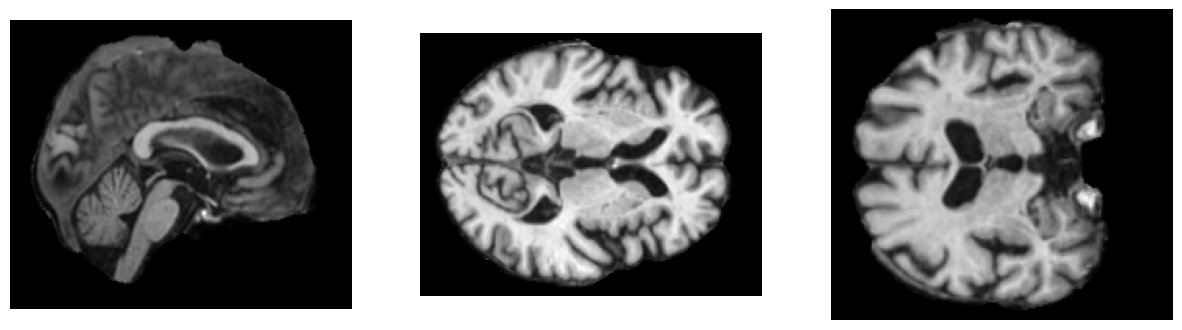

In [4]:
import numpy as np

# Path to your .npz file
file_path = "/mimer/NOBACKUP/groups/biomedicalimaging-kth/felixnie/batched_adni/batch_0005.npz"

# Load the file
data = np.load(file_path)

# Show keys available in the file
print("Keys:", data.files)

# Example: Load one image and segmentation
image = data['images'][0]
segmentation = data['segmentations'][0]
sample_id = data['ids'][0]

# Optionally: close file if it's a lazy loader (not strictly needed if you load all arrays)
data.close()

# Confirm shapes and types
print("Image shape:", image.shape)
print("Segmentation shape:", segmentation.shape)
print("Sample ID:", sample_id)

# Show a single slice (assuming 3D MRI data)
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
axes[0].imshow(image[image.shape[0] // 2, : ,:], cmap="gray")
axes[0].axis("off")
axes[1].imshow(image[:, image.shape[1] // 2, :], cmap="gray")
axes[1].axis("off")
axes[2].imshow(image[:, :, image.shape[2] // 2], cmap="gray")
axes[2].axis("off")
plt.show()


In [3]:
import torch
from torch.utils.data import Dataset
import numpy as np
import pandas as pd
import gc

class LookupNPZDataset(Dataset):
    def __init__(self, df, use_segmentation=True):
        self.df = df.reset_index(drop=True)
        self.use_segmentation = use_segmentation

        self.current_batch_file = None
        self.current_batch_data = None
        self.current_batch_indices = []
        self.local_pointer = 0
        self.batch_files = set(sorted(self.df["batch_file"].unique()))
        self.remaining_batch_files = self.batch_files

    def __len__(self):
        return len(self.df)

    def _load_batch(self, batch_file):
        if self.current_batch_data is not None:
            del self.current_batch_data
            gc.collect()

        self.current_batch_file = batch_file
        npz_data = np.load(batch_file)

        self.current_batch_data = {
            "images": np.array(npz_data["images"]),
            "ids": np.array(npz_data["ids"]),
        }

        if self.use_segmentation and "segmentations" in npz_data:
            self.current_batch_data["segmentations"] = np.array(npz_data["segmentations"])

        npz_data.close()

        self.current_batch_indices = self.df[self.df["batch_file"] == batch_file].index.tolist()
        np.random.shuffle(self.current_batch_indices)
        self.local_pointer = 0

    def __getitem__(self, _):
        if (
            self.current_batch_data is None or
            self.local_pointer >= len(self.current_batch_indices)
        ):
            self.remaining_batch_files = self.remaining_batch_files - {self.current_batch_file}
            if not self.remaining_batch_files:
                self.remaining_batch_files = self.batch_files
            next_batch_file = list(self.remaining_batch_files)[0]
            self._load_batch(next_batch_file)

        df_idx = self.current_batch_indices[self.local_pointer]
        row = self.df.iloc[df_idx]
        index_in_batch = row["index_in_batch"]
        sample_id = row["id"]
        image = self.current_batch_data["images"][index_in_batch]
        self.local_pointer += 1

        sample = {
            "id": sample_id,
            "image": torch.from_numpy(image)
        }
        if self.use_segmentation:
            seg = self.current_batch_data["segmentations"][index_in_batch]
            sample["seg"] = torch.from_numpy(seg)

        return sample


In [21]:
from torch.utils.data import DataLoader

# Load your prefiltered CSV (merged with clinical metadata)
df = pd.read_csv("/mimer/NOBACKUP/groups/biomedicalimaging-kth/felixnie/dataset_index.csv")
df = df.iloc[3000:3002]

dataset = LookupNPZDataset(df)
loader = DataLoader(dataset, batch_size=4, num_workers=0)

# Example training loop
for batch in loader:
    # batch is a list of dicts
    images = batch['image']
    segs = batch['seg'] if "seg" in batch else None
    ids = batch['id']
    halt

NameError: name 'halt' is not defined

In [20]:
df = pd.read_csv("/mimer/NOBACKUP/groups/biomedicalimaging-kth/felixnie/dataset_index.csv")
df = df.iloc[3000:3002]
df

,id,dataset,batch_file,index_in_batch,index_global
3000,009710be-940b-4d48-9be7-e29da6995240,ADNI,/mimer/NOBACKUP/groups/biomedicalimaging-kth/f...,319,3000
3001,0097b04c-123d-484a-9005-09136c39dc21,ADNI,/mimer/NOBACKUP/groups/biomedicalimaging-kth/f...,320,3001


In [22]:
mri_image = images[0].detach().cpu().numpy()
mri_image

array([[[0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        ...,
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0]],

       [[0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        ...,
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0]],

       [[0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        ...,
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0]],

       ...,

       [[0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        ...,
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0]],

       [[0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        ...,
        [0, 0, 0, ..., 

In [23]:
ids

['0097b04c-123d-484a-9005-09136c39dc21',
 '009710be-940b-4d48-9be7-e29da6995240']

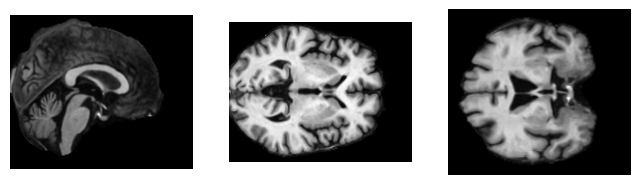

In [24]:
# Show a single slice (assuming 3D MRI data)
fig, axes = plt.subplots(1, 3, figsize=(8, 10))
axes[0].imshow(mri_image[mri_image.shape[0] // 2, : ,:], cmap="gray")
axes[0].axis("off")
axes[1].imshow(mri_image[:, mri_image.shape[1] // 2, :], cmap="gray")
axes[1].axis("off")
axes[2].imshow(mri_image[:, :, mri_image.shape[2] // 2], cmap="gray")
axes[2].axis("off")
plt.show()

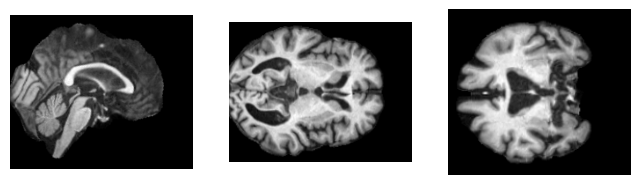

In [9]:
# Show a single slice (assuming 3D MRI data)
fig, axes = plt.subplots(1, 3, figsize=(8, 10))
axes[0].imshow(mri_image[mri_image.shape[0] // 2, : ,:], cmap="gray")
axes[0].axis("off")
axes[1].imshow(mri_image[:, mri_image.shape[1] // 2, :], cmap="gray")
axes[1].axis("off")
axes[2].imshow(mri_image[:, :, mri_image.shape[2] // 2], cmap="gray")
axes[2].axis("off")
plt.show()